In [1]:
# =========================================
# 1️⃣ Import Required Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')


In [2]:
# =========================================
# 2️⃣ Load and Inspect the Dataset
# =========================================
df = pd.read_csv("Mall_Customers.csv")   # Adjust path if needed
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Check basic info and missing values
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
# =========================================
# 3️⃣ Data Cleaning and Feature Selection
# =========================================
# Drop non-useful columns
df = df.drop(['CustomerID'], axis=1)

# Encode Gender (Male=0, Female=1)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Select numeric features for clustering
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]


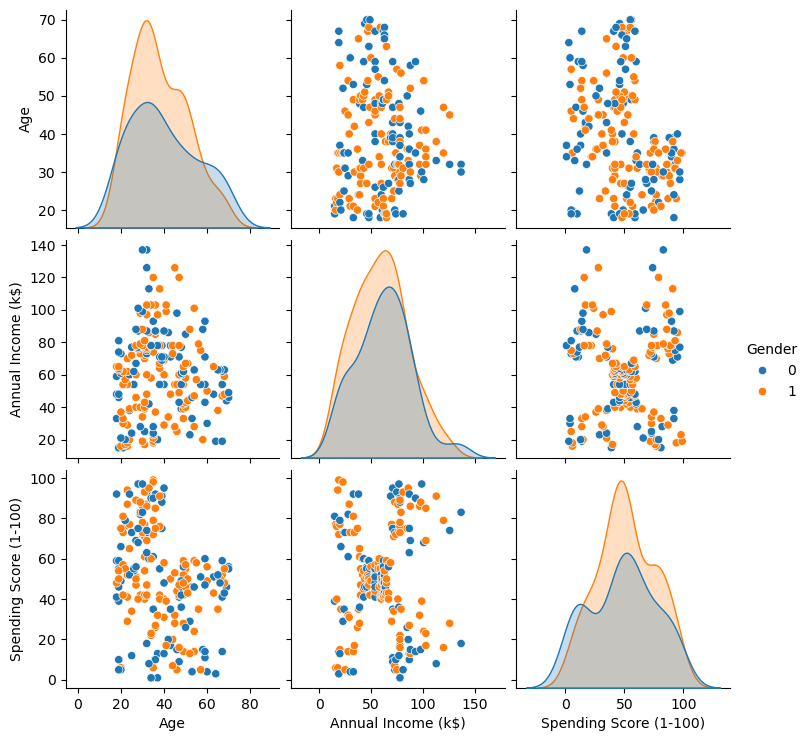

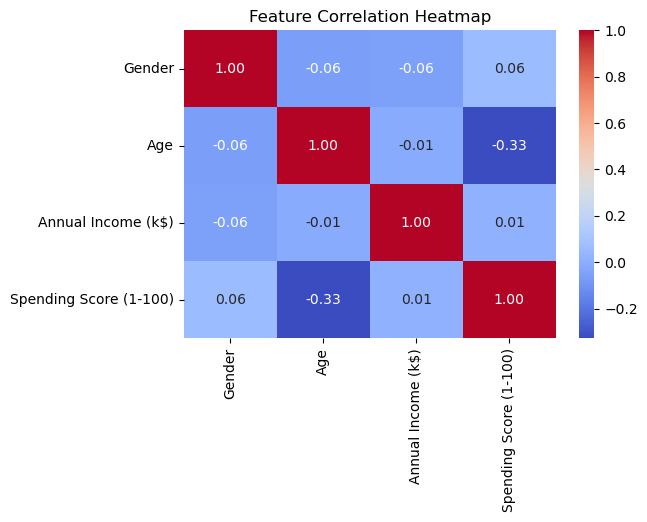

In [5]:
# =========================================
# 4️⃣ Exploratory Data Analysis (EDA)
# =========================================
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Gender')
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


In [6]:
# =========================================
# 5️⃣ Feature Scaling
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Sample:")
print(X_scaled[:5])


Scaled Feature Sample:
[[-1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [-1.12815215 -1.28103541 -1.73899919  1.19570407]
 [ 0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [ 0.88640526 -1.13750203 -1.70082976  1.04041783]
 [ 0.88640526 -0.56336851 -1.66266033 -0.39597992]]


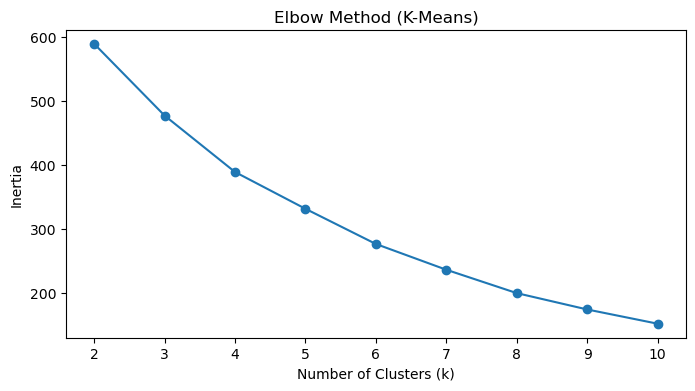

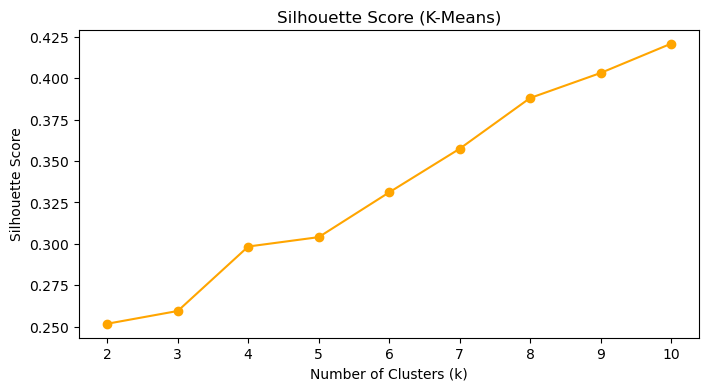

In [7]:
# =========================================
# 6️⃣ K-Means Clustering
# =========================================

# Find optimal number of clusters (Elbow + Silhouette)
inertia = []
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
plt.figure(figsize=(8,4))
plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method (K-Means)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8,4))
plt.plot(range(2,11), silhouette, marker='o', color='orange')
plt.title('Silhouette Score (K-Means)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()


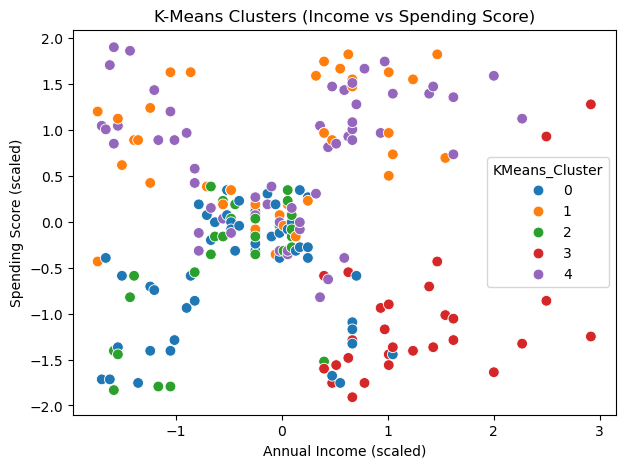

K-Means Silhouette: 0.31437614343154285
K-Means Davies-Bouldin: 1.1364140131500382
K-Means Calinski-Harabasz: 70.38799130825487


In [8]:
# =========================================
# 7️⃣ Apply K-Means with Optimal k
# =========================================
best_k = 5  # choose based on plots
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X_scaled[:,2], y=X_scaled[:,3],
    hue=df['KMeans_Cluster'], palette='tab10', s=60
)
plt.title('K-Means Clusters (Income vs Spending Score)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

# Evaluate
print("K-Means Silhouette:", silhouette_score(X_scaled, df['KMeans_Cluster']))
print("K-Means Davies-Bouldin:", davies_bouldin_score(X_scaled, df['KMeans_Cluster']))
print("K-Means Calinski-Harabasz:", calinski_harabasz_score(X_scaled, df['KMeans_Cluster']))


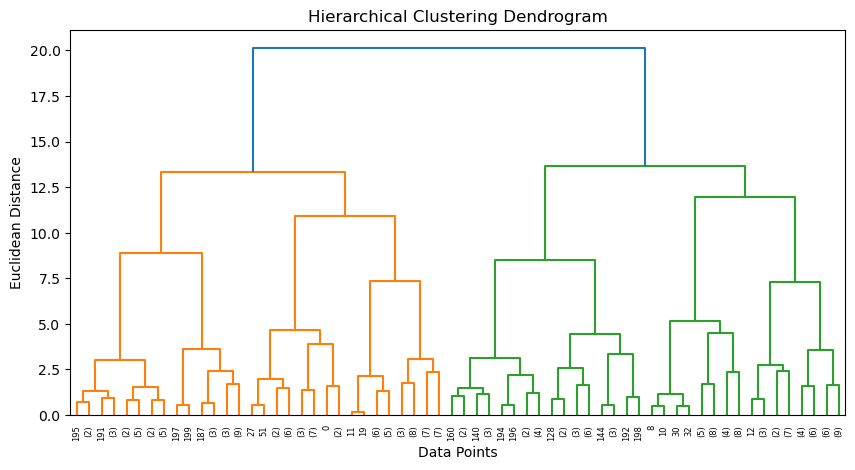

Agglomerative Silhouette: 0.28699413201651747
Agglomerative Davies-Bouldin: 1.2197730790225614
Agglomerative Calinski-Harabasz: 64.46870730105833


In [9]:
# =========================================
# 8️⃣ Hierarchical Clustering
# =========================================

# Dendrogram (Ward linkage)
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

# Fit Agglomerative Clustering with same number of clusters
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Agglomerative_Cluster'] = agg.fit_predict(X_scaled)

# Evaluate
print("Agglomerative Silhouette:", silhouette_score(X_scaled, df['Agglomerative_Cluster']))
print("Agglomerative Davies-Bouldin:", davies_bouldin_score(X_scaled, df['Agglomerative_Cluster']))
print("Agglomerative Calinski-Harabasz:", calinski_harabasz_score(X_scaled, df['Agglomerative_Cluster']))


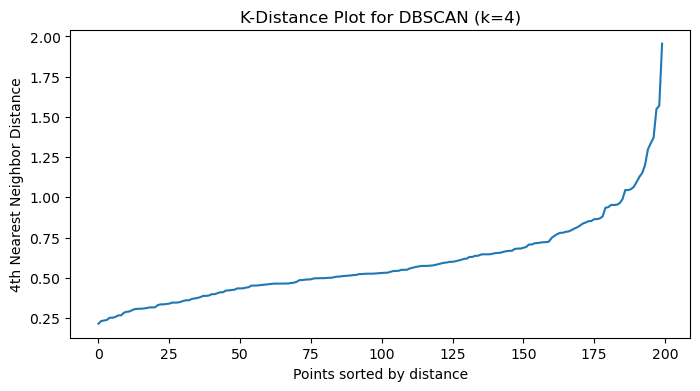

DBSCAN Silhouette: 0.13577223739354735


In [10]:
# =========================================
# 9️⃣ DBSCAN Clustering
# =========================================

# Find suitable eps using k-distance plot
nbrs = NearestNeighbors(n_neighbors=4).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title('K-Distance Plot for DBSCAN (k=4)')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance')
plt.show()

# Apply DBSCAN (adjust eps after checking plot)
dbscan = DBSCAN(eps=0.7, min_samples=4)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Evaluate (if at least 2 clusters found)
if len(set(df['DBSCAN_Cluster'])) > 1 and -1 not in df['DBSCAN_Cluster']:
    print("DBSCAN Silhouette:", silhouette_score(X_scaled, df['DBSCAN_Cluster']))
else:
    print("DBSCAN found limited clusters or noise, adjust eps/min_samples.")


,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,48.791667,50.333333,36.395833
1,28.410256,58.230769,70.717949
2,57.214286,46.785714,38.714286
3,38.896552,94.172414,21.827586
4,28.392857,60.428571,68.178571


KMeans_Cluster
4    56
0    48
1    39
3    29
2    28
Name: count, dtype: int64


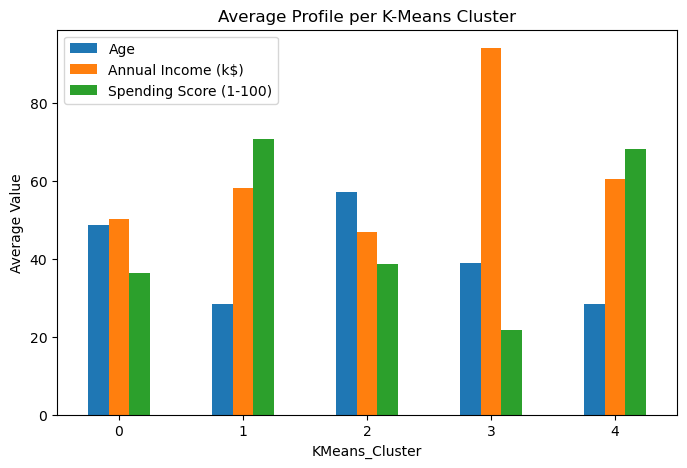

In [11]:
# =========================================
# 🔟 Cluster Profiling (K-Means)
# =========================================
cluster_summary = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(cluster_summary)

# Cluster counts
print(df['KMeans_Cluster'].value_counts())

# Visualize cluster profiles
cluster_summary.plot(kind='bar', figsize=(8,5))
plt.title('Average Profile per K-Means Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()


In [12]:
# =========================================
# 11️⃣ Save Results
# =========================================
df.to_csv("Mall_Customers_Clustered.csv", index=False)
print("Clustered dataset saved successfully!")


Clustered dataset saved successfully!
